In [13]:
# 参考: https://qiita.com/Mikeinu/items/dd5e9af26fd3a5f3c8e0

In [22]:
from janome.tokenizer import Tokenizer
import unicodedata
import MeCab
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
from PIL import Image, ImageDraw, ImageFont
import os
from datetime import datetime


In [23]:
def filter_df(
    df: pd.DataFrame,
    start_date_str: str,
    end_date_str: str,
) -> pd.DataFrame:
    # 日付でフィルタリング
    start_date = pd.to_datetime(start_date_str)
    end_date = pd.to_datetime(end_date_str)

    df['timestamp_jst'] = df['timestamp_jst'].astype('datetime64[ns]')

    filtered_df_tmp = df[df['timestamp_jst'] >= start_date].copy()
    filtered_df = filtered_df_tmp[filtered_df_tmp['timestamp_jst'] <= end_date].copy()
    filtered_df.reset_index(drop=True, inplace=True)
    return filtered_df

In [24]:
def clean_text(text: str) -> str:
    # re.subで正規表現を使った文字列の削除
    text = re.sub('\u3000', '', text)
    text = re.sub('・', '', text)
    text = re.sub('「', '', text)
    text = re.sub('」', '', text)
    text = re.sub('（', '', text)
    text = re.sub('）', '', text)
    
    # re.subで正規表現を使った文字列の半角空白への置換
    text = re.sub('\n', ' ', text)
    text = re.sub('\\n', '', text)
    text = re.sub('\\n', ' ', text)
    return text

In [25]:
def tokenized_text(text: str) -> list:

    # ユニコード正規化
    normalized_text = unicodedata.normalize('NFKC', text)
    t = Tokenizer()
    tokenized_text = t.tokenize(normalized_text)

    words_list=[]
    #tokenizeされたテキストをfor文を使ってhinshiとhinshi2に格納する。
    for token in tokenized_text:
        tokenized_word = token.surface
        hinshi = token.part_of_speech.split(',')[0]
        hinshi2 = token.part_of_speech.split(',')[1]
        #抜き出す品詞を指定する
        if hinshi == "名詞":
            if (hinshi2 != "数") and (hinshi2 != "代名詞") and (hinshi2 != "非自立"):
                words_list.append(tokenized_word)

    words_wakachi = " ".join(words_list)

    return words_wakachi

In [26]:
def generate_wordcloud(words_wakachi: str, stop_words, title: str,  font_path:str) -> None:
    # WordCloudを生成（ここではまだ画像化しない）
    word_cloud_obj = WordCloud(font_path=font_path,
                                width=1500,
                                height=900,
                                stopwords=set(stop_words),
                                min_font_size=5,
                                collocations=False,
                                background_color='white',
                                max_words=400).generate(words_wakachi)

    # figureとグリッドを作成
    # タイトル用のスペースを考慮して、全体の高さを少し大きく設定
    fig = plt.figure(figsize=(15, 10 + 1)) # 高さを少し追加 (例: 10 + 1インチ)
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 10]) # 上段をタイトル用、下段をWordCloud用

    # --- タイトル用のサブプロット ---
    ax_title = fig.add_subplot(gs[0, 0])
    ax_title.text(0.5, 0.5, title, ha='center', va='center',
                  fontsize=30, color='black') # フォントサイズを調整
    ax_title.axis('off') # 軸を非表示

    # --- WordCloud用のサブプロット ---
    ax_wordcloud = fig.add_subplot(gs[1, 0])
    ax_wordcloud.imshow(word_cloud_obj, interpolation='bilinear')
    ax_wordcloud.axis('off') # 軸を非表示

    plt.tight_layout(rect=[0, 0, 1, 0.95]) # 全体のレイアウトを調整し、上部に少し余白を確保
    plt.show()

    return fig

In [27]:
def main(df, start_date_str, end_date_str, font_path, output_dir):
    
    filtered_df = filter_df(
        df=df,
        start_date_str=start_date_str,
        end_date_str=end_date_str,
    )

    # 日付の最大値・最小値を取得してタイトルに反映する
    min_timestamp_str = filtered_df['timestamp_jst'].min().strftime('%Y-%m-%d')
    max_timestamp_str = filtered_df['timestamp_jst'].max().strftime('%Y-%m-%d')
    title = f"{min_timestamp_str} ~ {max_timestamp_str}"

    # caption列を結合
    whole_words = ''.join(filtered_df['caption'].astype(str))

    # テキストの前処理と形態素解析
    cleaned_text = clean_text(whole_words)
    words_wakachi = tokenized_text(cleaned_text)

    # 除外するワードを設定
    stop_words = ['こと', 'よう', 'それ', 'もの', 'さん', 'ため', 'ところ', 'これ',
                '私', '今日', '明日', '昨日', '時', '日','年', '月', '週', '分',
                '様', '自分', '皆', '人', '目', 'あと', '笑', '泣', '話', '好き', '前', '円',
                'コマ',
                'あ', 'い', 'う', 'え', 'お', 'か', 'き', 'く', 'け', 'こ', 
                'さ', 'し', 'す', 'せ', 'そ', 'た', 'ち', 'つ', 'て', 'と',
                'な', 'に', 'ぬ', 'ね', 'の', 'は', 'ひ', 'ふ', 'へ', 'ほ',
                'ま', 'み', 'む', 'め', 'も', 'や', 'ゆ', 'よ', 'ら', 'り',
                'る', 'れ', 'ろ', 'わ', 'を', 'ん']
    # ワードクラウドの生成と表示
    fig = generate_wordcloud(words_wakachi, stop_words, title, font_path)

    # 今日の日付を取得 (例: 20240520)
    today_str = datetime.now().strftime('%Y%m%d')
    
    # ファイル名に日付を組み込む
    save_name = f"wordcloud_from_{min_timestamp_str}_to_{max_timestamp_str}_{today_str}.png"
    save_path = os.path.join(output_dir, save_name)
    
    # 画像として保存
    fig.savefig(save_path, dpi=300)
    print(f"グラフを保存しました: {save_path}")

## データを読み込む

In [28]:
file_path = '/Users/st/workspace/instagram/data/output/results_master.csv'
font_path = '/Users/st/workspace/instagram/assets/fonts/NotoSansJP-VariableFont_wght.ttf'
output_dir = os.path.dirname(file_path)

try:
    results_df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: {file_path} が見つかりませんでした。")

# 2023年

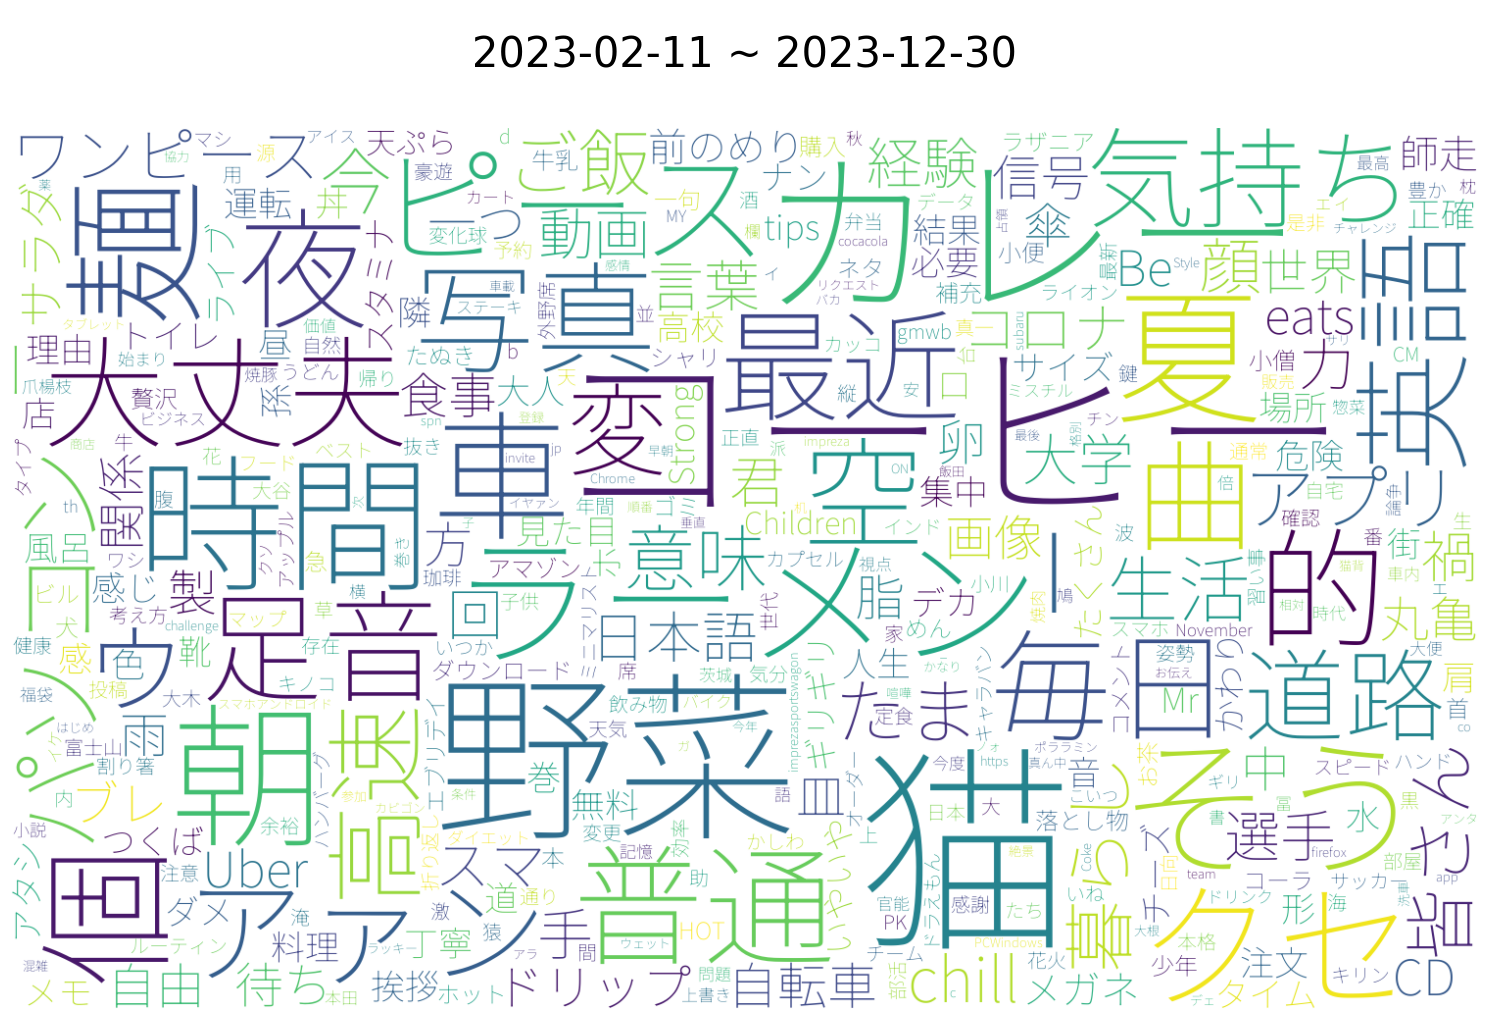

グラフを保存しました: /Users/st/workspace/instagram/data/output/wordcloud_from_2023-02-11_to_2023-12-30_20260111.png


In [29]:
# dfを日付でフィルタリング
start_date_str = "2023-02-10"  # 毎日投稿を始めたのが2023年2月10日
end_date_str = "2023-12-31"
main(results_df, start_date_str, end_date_str, font_path=font_path, output_dir=output_dir)

## 2024年

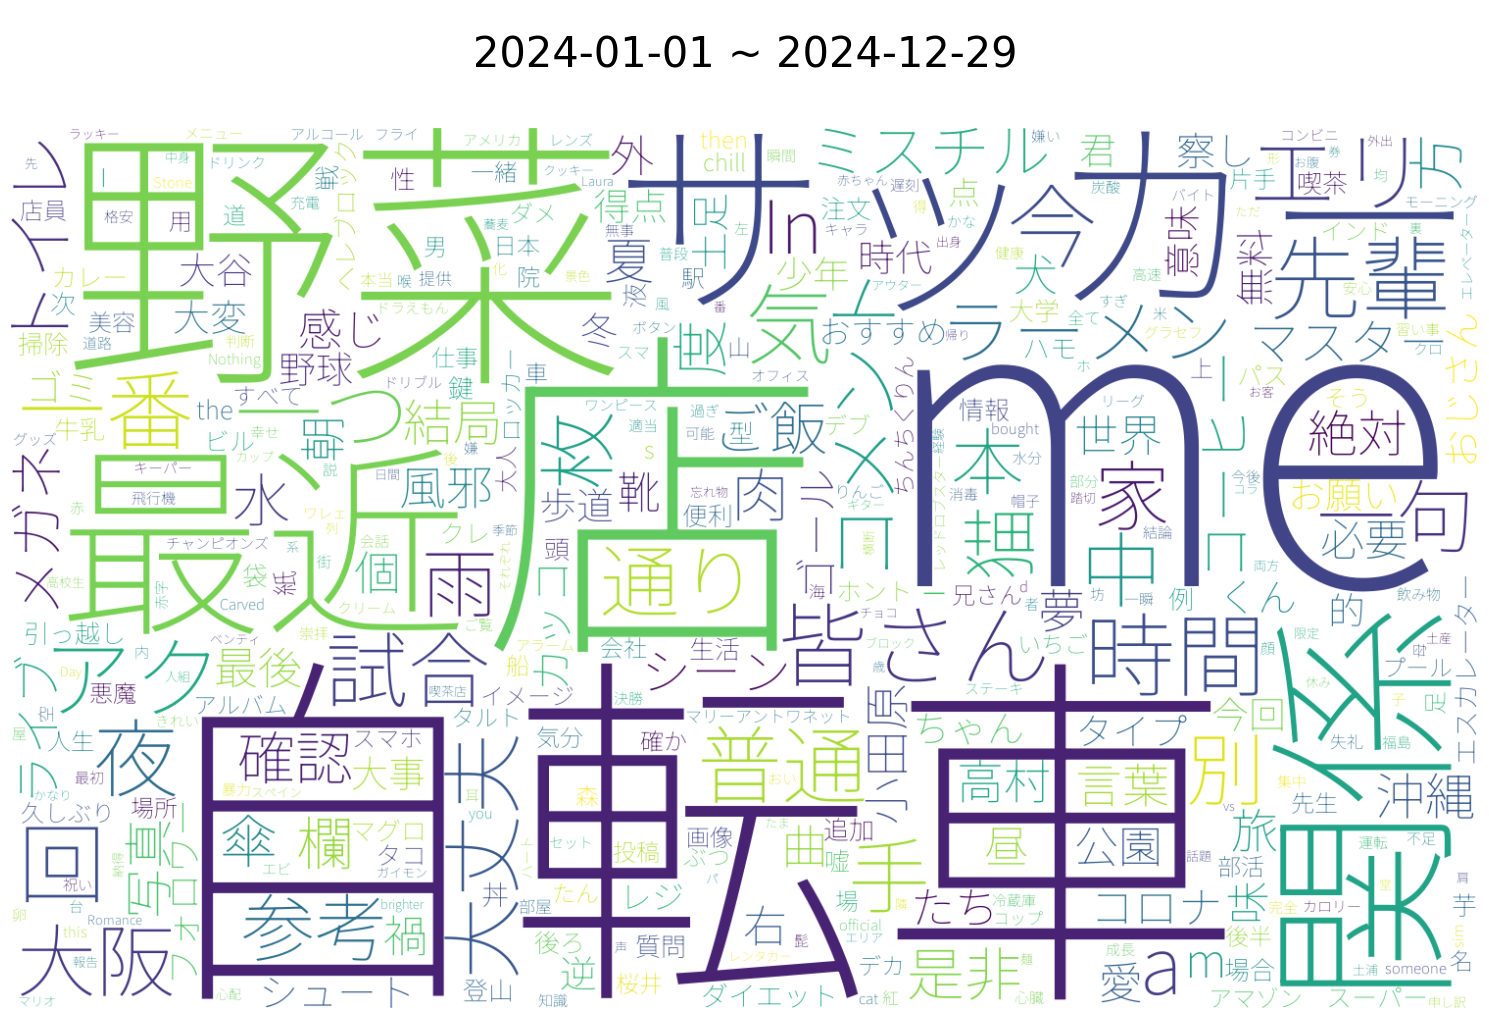

グラフを保存しました: /Users/st/workspace/instagram/data/output/wordcloud_from_2024-01-01_to_2024-12-29_20260111.png


In [30]:
# dfを日付でフィルタリング
start_date_str = "2024-01-01"
end_date_str = "2024-12-31"
main(results_df, start_date_str, end_date_str, font_path=font_path, output_dir=output_dir)

## 2025年

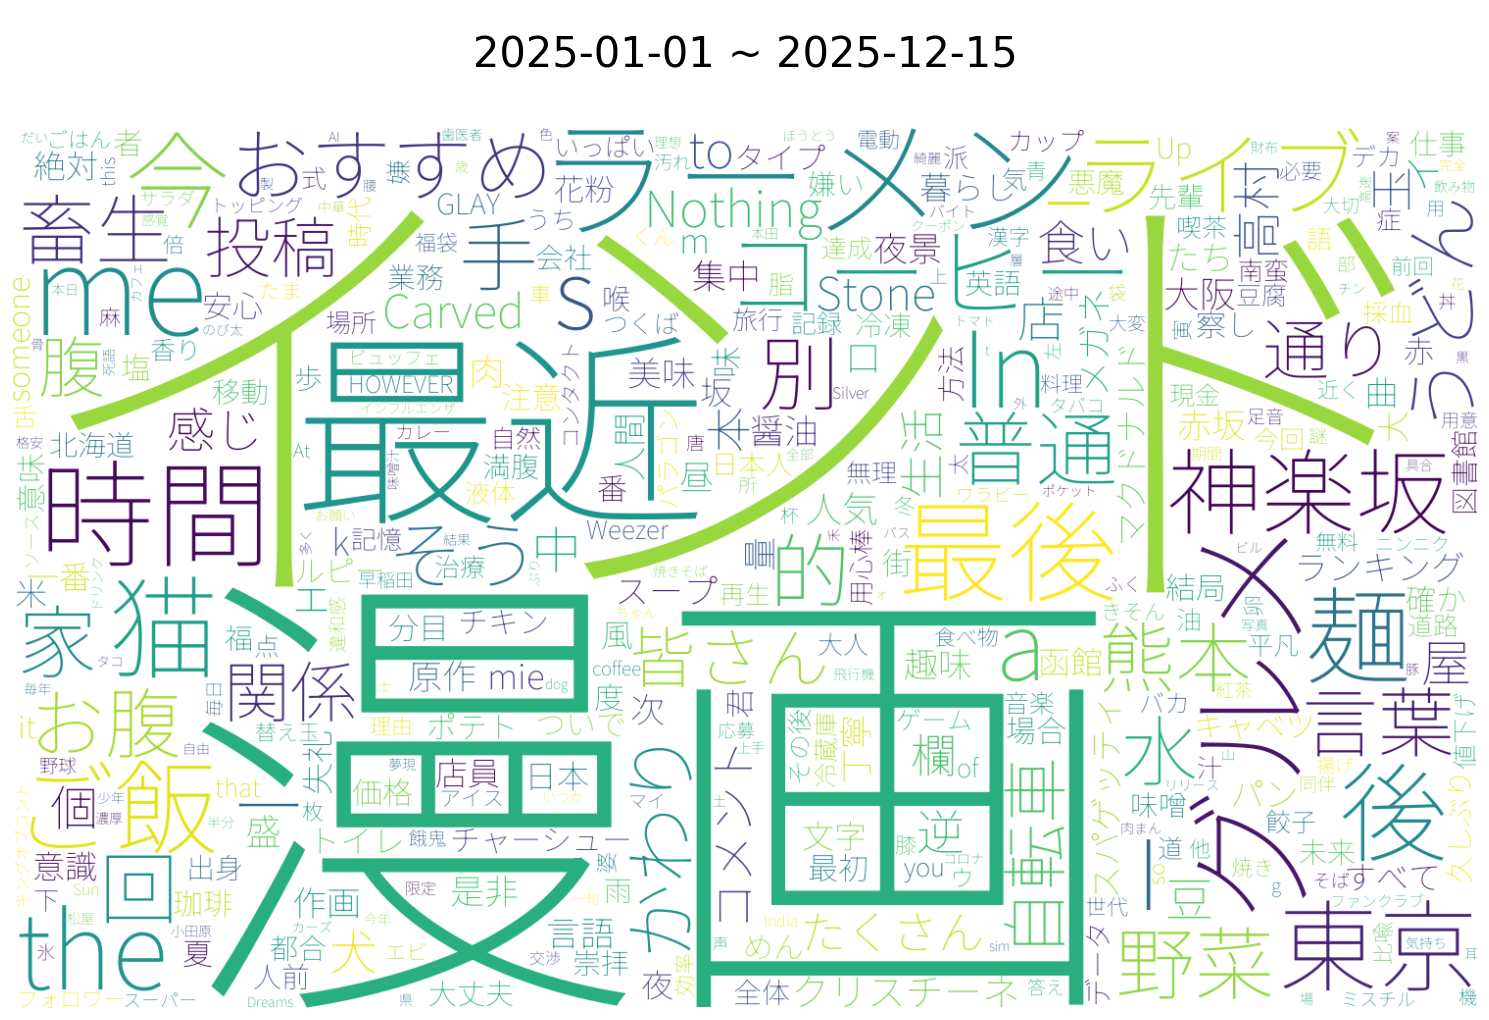

グラフを保存しました: /Users/st/workspace/instagram/data/output/wordcloud_from_2025-01-01_to_2025-12-15_20260111.png


In [31]:
# dfを日付でフィルタリング
start_date_str = "2025-01-01"
end_date_str = "2025-12-31"
main(results_df, start_date_str, end_date_str, font_path=font_path, output_dir=output_dir)